In [26]:
import seaborn as sns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

Saving weatherdata.csv to weatherdata.csv


In [2]:
weather_df=pd.read_csv('weatherdata.csv')

In [3]:
weather_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0


In [4]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
dtypes: float64(6), object(3)
memory usage: 9.8+ MB


In [5]:
weather_df["Date"]=pd.to_datetime(weather_df["Date"],errors='coerce')

In [6]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[ns]
 1   Location       142193 non-null  object        
 2   MinTemp        141556 non-null  float64       
 3   MaxTemp        141871 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   Evaporation    81350 non-null   float64       
 6   Sunshine       74377 non-null   float64       
 7   WindGustDir    132863 non-null  object        
 8   WindGustSpeed  132923 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 9.8+ MB


In [7]:
weather_df.isna().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270


In [8]:
len(weather_df)

142193

In [9]:
empty_rows_filter = weather_df.iloc[:, 2:].isna().all(axis=1)
print(empty_rows_filter.sum())
print(weather_df[empty_rows_filter])

8
             Date       Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
4857   2014-06-13  BadgerysCreek      NaN      NaN       NaN          NaN   
15424  2010-10-28      Newcastle      NaN      NaN       NaN          NaN   
15560  2011-03-18      Newcastle      NaN      NaN       NaN          NaN   
16208  2013-04-20      Newcastle      NaN      NaN       NaN          NaN   
16888  2015-03-20      Newcastle      NaN      NaN       NaN          NaN   
17220  2016-02-29      Newcastle      NaN      NaN       NaN          NaN   
96367  2015-11-21       Adelaide      NaN      NaN       NaN          NaN   
109018 2009-02-05    Witchcliffe      NaN      NaN       NaN          NaN   

        Sunshine WindGustDir  WindGustSpeed  
4857         NaN         NaN            NaN  
15424        NaN         NaN            NaN  
15560        NaN         NaN            NaN  
16208        NaN         NaN            NaN  
16888        NaN         NaN            NaN  
17220        NaN         NaN

In [10]:
# Removing 8 rows that contained no weather observations (only Date/Location)
weather_df = weather_df.dropna(subset=weather_df.columns[2:], how='all')

In [11]:
len(weather_df)

142185

In [12]:
weather_df["RainyDays"]=(weather_df["Rainfall"]>0).astype(int)
weather_df["HeavyRainDays"]=(weather_df["Rainfall"]>20).astype(int)
weather_df["Temp_Range"]=weather_df["MaxTemp"]-weather_df["MinTemp"]

In [13]:
weather_df["Year"]=weather_df["Date"].dt.year
weather_df["Month"]=weather_df["Date"].dt.month

In [14]:
print(weather_df)

             Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0      2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1      2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2      2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3      2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4      2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   
...           ...      ...      ...      ...       ...          ...       ...   
142188 2017-06-20    Uluru      3.5     21.8       0.0          NaN       NaN   
142189 2017-06-21    Uluru      2.8     23.4       0.0          NaN       NaN   
142190 2017-06-22    Uluru      3.6     25.3       0.0          NaN       NaN   
142191 2017-06-23    Uluru      5.4     26.9       0.0          NaN       NaN   
142192 2017-06-24    Uluru      7.8     27.0       0.0          NaN       NaN   

       WindGustDir  WindGus

In [15]:
# group data by Location
# 1. creating a copy of dataframe to preserve the original
# 2. drop date coloumn
# 3. group data using group by Location

df_location=weather_df.copy()

In [16]:
df_location.drop(columns=["Date","Year","Month"],inplace=True)

In [ ]:
df_location

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,RainyDays,HeavyRainDays,Temp_Range
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,1,0,9.5
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,0,0,17.7
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,0,0,12.8
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,0,0,18.8
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,1,0,14.8
...,...,...,...,...,...,...,...,...,...,...,...
142188,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,0,0,18.3
142189,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,0,0,20.6
142190,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,0,0,21.7
142191,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,0,0,21.5


In [17]:
df_location.isna().sum()

,0
Location,0
MinTemp,629
MaxTemp,314
Rainfall,1398
Evaporation,60835
Sunshine,67808
WindGustDir,9322
WindGustSpeed,9262
RainyDays,0
HeavyRainDays,0


In [18]:
df_location.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142185 entries, 0 to 142192
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142185 non-null  object 
 1   MinTemp        141556 non-null  float64
 2   MaxTemp        141871 non-null  float64
 3   Rainfall       140787 non-null  float64
 4   Evaporation    81350 non-null   float64
 5   Sunshine       74377 non-null   float64
 6   WindGustDir    132863 non-null  object 
 7   WindGustSpeed  132923 non-null  float64
 8   RainyDays      142185 non-null  int64  
 9   HeavyRainDays  142185 non-null  int64  
 10  Temp_Range     141322 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 13.0+ MB


In [19]:
df_location=df_location.groupby(by=["Location"]).agg(Avg_Mintemp=("MinTemp","mean"),
                                                     Avg_MaxTemp=("MaxTemp","mean"),
                                                     Avg_Rainfall=("Rainfall","mean"),
                                                     Avg_Evaporation=("Evaporation","mean"),
                                                     Avg_Sunshine=("Sunshine","mean"),
                                                     Avg_WindSpeed=("WindGustSpeed","mean"),

                                                     RainDays_Percentage=("RainyDays","mean"),
                                                     HeavyRainDays_Percentage=("HeavyRainDays","mean"),
                                                     Rainfall_std=("Rainfall","std"),

                                                     Avg_TempRange=("Temp_Range","mean"),
                                                     TempRange_std=("Temp_Range","std"),
                                                     Wind_Dir=("WindGustDir", lambda x: x.mode().get(0, np.nan))
                                                    ).reset_index()

In [20]:
df_location.head()

,Location,Avg_Mintemp,Avg_MaxTemp,Avg_Rainfall,Avg_Evaporation,Avg_Sunshine,Avg_WindSpeed,RainDays_Percentage,HeavyRainDays_Percentage,Rainfall_std,Avg_TempRange,TempRange_std,Wind_Dir
0,Adelaide,12.628368,22.945402,1.572185,5.824924,7.752002,36.530812,0.334736,0.011007,4.588956,10.318691,4.501224,WSW
1,Albany,12.948461,20.072587,2.255073,4.207273,6.658765,NaN,0.443966,0.018236,5.106656,7.087150,3.287874,NaN
2,Albury,9.520899,22.630963,1.925710,NaN,NaN,32.953016,0.329791,0.019927,6.249052,13.114214,4.643737,W
3,AliceSprings,13.125182,29.244191,0.869355,9.029929,9.581944,40.533714,0.120092,0.012207,4.432703,16.121327,4.976520,ESE
4,BadgerysCreek,11.136900,24.023111,2.207925,NaN,NaN,33.609890,0.332081,0.030748,7.431759,12.883185,4.952732,SW


In [21]:
df_location

,Location,Avg_Mintemp,Avg_MaxTemp,Avg_Rainfall,Avg_Evaporation,Avg_Sunshine,Avg_WindSpeed,RainDays_Percentage,HeavyRainDays_Percentage,Rainfall_std,Avg_TempRange,TempRange_std,Wind_Dir
0,Adelaide,12.628368,22.945402,1.572185,5.824924,7.752002,36.530812,0.334736,0.011007,4.588956,10.318691,4.501224,WSW
1,Albany,12.948461,20.072587,2.255073,4.207273,6.658765,NaN,0.443966,0.018236,5.106656,7.087150,3.287874,NaN
2,Albury,9.520899,22.630963,1.925710,NaN,NaN,32.953016,0.329791,0.019927,6.249052,13.114214,4.643737,W
3,AliceSprings,13.125182,29.244191,0.869355,9.029929,9.581944,40.533714,0.120092,0.012207,4.432703,16.121327,4.976520,ESE
4,BadgerysCreek,11.136900,24.023111,2.207925,NaN,NaN,33.609890,0.332081,0.030748,7.431759,12.883185,4.952732,SW
5,Ballarat,7.355302,18.274794,1.688830,NaN,NaN,44.978695,0.448811,0.011889,4.675222,10.916457,5.086544,N
6,Bendigo,8.591065,21.616683,1.621452,3.851730,NaN,38.849283,0.357943,0.017139,5.188193,13.022724,4.978218,SSE
7,Brisbane,16.410998,26.441527,3.160536,5.408848,8.082782,28.211380,0.353369,0.043024,11.602227,10.025674,3.053393,E
8,Cairns,21.199197,29.544344,5.765317,6.211976,7.575995,38.067991,0.447122,0.076640,18.347196,8.346267,2.450957,SE
9,Canberra,6.827688,20.980644,1.735038,4.404717,7.403241,40.082174,0.290228,0.019895,5.709046,14.138757,5.032573,NW


In [22]:
df_location.isna().sum()

,0
Location,0
Avg_Mintemp,0
Avg_MaxTemp,0
Avg_Rainfall,0
Avg_Evaporation,16
Avg_Sunshine,19
Avg_WindSpeed,2
RainDays_Percentage,0
HeavyRainDays_Percentage,0
Rainfall_std,0


In [23]:
df_location["Moisture_Index"]=(df_location["Avg_Rainfall"]-df_location["Avg_Evaporation"])

In [30]:
df_location["Rainfall_std_norm"] = (
    df_location["Rainfall_std"] - df_location["Rainfall_std"].min()
) / (df_location["Rainfall_std"].max() - df_location["Rainfall_std"].min())

df_location["Temp_std_norm"] = (
    df_location["TempRange_std"] - df_location["TempRange_std"].min()
) / (df_location["TempRange_std"].max() - df_location["TempRange_std"].min())

df_location["Climate_Variability_Score"] = (
    df_location["Rainfall_std_norm"] + df_location["Temp_std_norm"]
) / 2

In [31]:
df_location

,Location,Avg_Mintemp,Avg_MaxTemp,Avg_Rainfall,Avg_Evaporation,Avg_Sunshine,Avg_WindSpeed,RainDays_Percentage,HeavyRainDays_Percentage,Rainfall_std,Avg_TempRange,TempRange_std,Wind_Dir,Moisture_Index,Rainfall_std_norm,Temp_std_norm,Climate_Variability_Score
0,Adelaide,12.628368,22.945402,1.572185,5.824924,7.752002,36.530812,0.334736,0.011007,4.588956,10.318691,4.501224,WSW,-4.252739,0.118729,0.725190,0.421959
1,Albany,12.948461,20.072587,2.255073,4.207273,6.658765,NaN,0.443966,0.018236,5.106656,7.087150,3.287874,NaN,-1.952200,0.151889,0.442086,0.296988
2,Albury,9.520899,22.630963,1.925710,NaN,NaN,32.953016,0.329791,0.019927,6.249052,13.114214,4.643737,W,NaN,0.225064,0.758442,0.491753
3,AliceSprings,13.125182,29.244191,0.869355,9.029929,9.581944,40.533714,0.120092,0.012207,4.432703,16.121327,4.976520,ESE,-8.160574,0.108720,0.836088,0.472404
4,BadgerysCreek,11.136900,24.023111,2.207925,NaN,NaN,33.609890,0.332081,0.030748,7.431759,12.883185,4.952732,SW,NaN,0.300822,0.830538,0.565680
5,Ballarat,7.355302,18.274794,1.688830,NaN,NaN,44.978695,0.448811,0.011889,4.675222,10.916457,5.086544,N,NaN,0.124254,0.861759,0.493007
6,Bendigo,8.591065,21.616683,1.621452,3.851730,NaN,38.849283,0.357943,0.017139,5.188193,13.022724,4.978218,SSE,-2.230278,0.157112,0.836484,0.496798
7,Brisbane,16.410998,26.441527,3.160536,5.408848,8.082782,28.211380,0.353369,0.043024,11.602227,10.025674,3.053393,E,-2.248311,0.567957,0.387376,0.477667
8,Cairns,21.199197,29.544344,5.765317,6.211976,7.575995,38.067991,0.447122,0.076640,18.347196,8.346267,2.450957,SE,-0.446659,1.000000,0.246813,0.623407
9,Canberra,6.827688,20.980644,1.735038,4.404717,7.403241,40.082174,0.290228,0.019895,5.709046,14.138757,5.032573,NW,-2.669679,0.190475,0.849166,0.519821


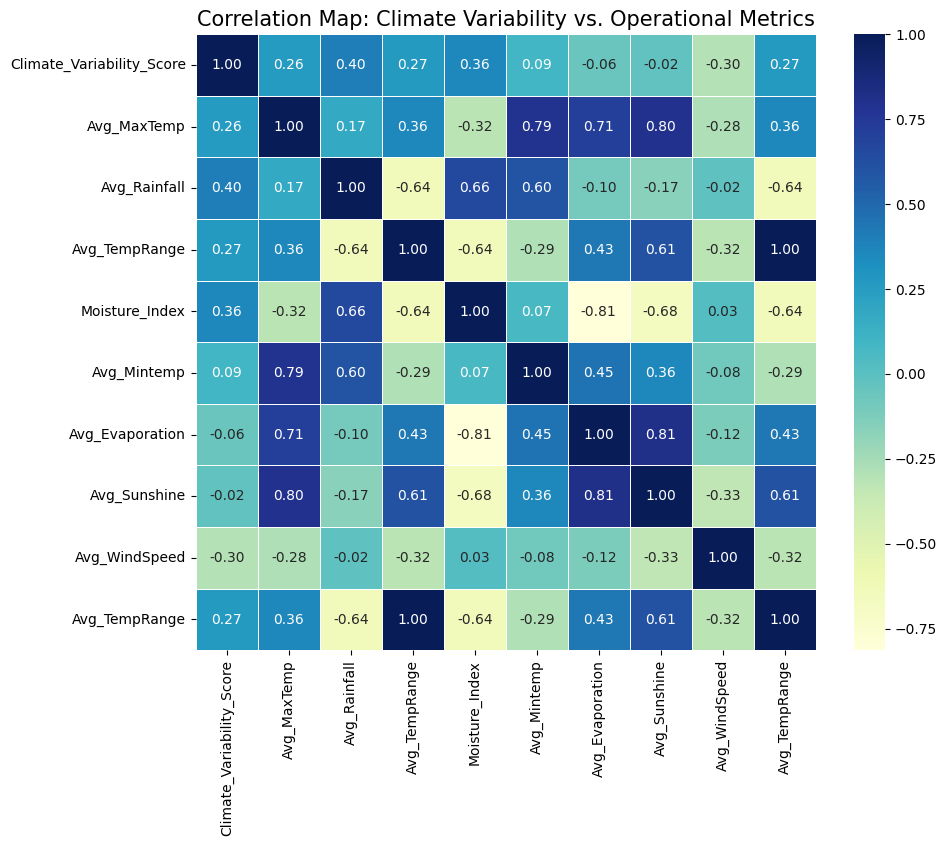

In [40]:
# Finding correlation between various columns of the dataset to get an idea about the relationship among the data.

correlation_cols = ['Climate_Variability_Score', 'Avg_MaxTemp', 'Avg_Rainfall',
                    'Avg_TempRange', 'Moisture_Index','Avg_Mintemp',
                    'Avg_Evaporation','Avg_Sunshine','Avg_WindSpeed','Avg_TempRange']

df_corr = df_location[correlation_cols].corr()


plt.figure(figsize=(10, 8))

sns.heatmap(df_corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)

plt.title('Correlation Map: Climate Variability vs. Operational Metrics', fontsize=15)
plt.show()

In [ ]:
df_location.to_csv("weather_data_loc_based.csv")

In [ ]:
weather_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,RainyDays,HeavyRainDays,Temp_Range,Year,Month
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,1,0,9.5,2008,12
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,0,0,17.7,2008,12
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,0,0,12.8,2008,12
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,0,0,18.8,2008,12
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,1,0,14.8,2008,12


In [ ]:
df_time = weather_df.copy()

In [ ]:
df_time.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,RainyDays,HeavyRainDays,Temp_Range,Year,Month
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,1,0,9.5,2008,12
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,0,0,17.7,2008,12
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,0,0,12.8,2008,12
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,0,0,18.8,2008,12
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,1,0,14.8,2008,12


In [ ]:
df_time.drop(columns=["Date"],inplace=True)

In [ ]:
print(df_time)

       Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0        Albury     13.4     22.9       0.6          NaN       NaN   
1        Albury      7.4     25.1       0.0          NaN       NaN   
2        Albury     12.9     25.7       0.0          NaN       NaN   
3        Albury      9.2     28.0       0.0          NaN       NaN   
4        Albury     17.5     32.3       1.0          NaN       NaN   
...         ...      ...      ...       ...          ...       ...   
142188    Uluru      3.5     21.8       0.0          NaN       NaN   
142189    Uluru      2.8     23.4       0.0          NaN       NaN   
142190    Uluru      3.6     25.3       0.0          NaN       NaN   
142191    Uluru      5.4     26.9       0.0          NaN       NaN   
142192    Uluru      7.8     27.0       0.0          NaN       NaN   

       WindGustDir  WindGustSpeed  RainyDays  HeavyRainDays  Temp_Range  Year  \
0                W           44.0          1              0         9.5  2008 

In [ ]:
df_location_year = df_time.groupby(["Location", "Year"]).agg(Avg_MinTemp=("MinTemp", "mean"),
                                                             Avg_MaxTemp=("MaxTemp", "mean"),
                                                             Avg_Rainfall=("Rainfall", "mean"),
                                                             Avg_Evaporation=("Evaporation", "mean"),
                                                             Avg_Sunshine=("Sunshine", "mean"),
                                                             Avg_WindSpeed=("WindGustSpeed", "mean"),
                                                             RainyDays_Percent=("RainyDays", "mean"),
                                                             HeavyRain_Percent=("HeavyRainDays", "mean"),
                                                             Rainfall_std=("Rainfall", "std"),
                                                             Avg_TempRange=("Temp_Range", "mean"),
                                                             TempRange_std=("Temp_Range", "std")
                                                             ).reset_index()

In [ ]:
print(df_location_year.head)

<bound method NDFrame.head of      Location  Year  Avg_MinTemp  Avg_MaxTemp  Avg_Rainfall  Avg_Evaporation  \
0    Adelaide  2008    11.090909    21.040606      1.487013         5.895000   
1    Adelaide  2009    13.170718    23.480387      1.431111         6.465882   
2    Adelaide  2010    12.675209    22.560446      1.668732         5.894737   
3    Adelaide  2011    12.987077    22.747385      1.555346         5.440088   
4    Adelaide  2012    12.074766    22.364486      1.598718         5.467544   
..        ...   ...          ...          ...           ...              ...   
448   Woomera  2013    13.268769    26.853293      0.397006        11.117794   
449   Woomera  2014    13.719452    27.529589      0.315616        13.486614   
450   Woomera  2015    13.476164    26.552329      0.434521        11.756089   
451   Woomera  2016    13.170868    26.223249      0.639718         9.013295   
452   Woomera  2017    14.990286    28.223429      0.589143         7.609859   

     Avg_

In [ ]:
df_location_month = df_time.groupby(["Location", "Month"]).agg(Avg_MinTemp=("MinTemp", "mean"),
                                                               Avg_MaxTemp=("MaxTemp", "mean"),
                                                               Avg_Rainfall=("Rainfall", "mean"),
                                                               RainyDays_Percent=("RainyDays", "mean"),
                                                               HeavyRain_Percent=("HeavyRainDays", "mean"),
                                                               Avg_TempRange=("Temp_Range", "mean")
                                                               ).reset_index()

In [ ]:
print(df_location_month.head)

<bound method NDFrame.head of      Location  Month  Avg_MinTemp  Avg_MaxTemp  Avg_Rainfall  \
0    Adelaide      1    18.079197    31.006204      0.772593   
1    Adelaide      2    17.850000    30.070982      0.883784   
2    Adelaide      3    15.947778    27.073704      1.213636   
3    Adelaide      4    12.922881    23.285169      1.434335   
4    Adelaide      5    10.755598    19.168340      2.252632   
..        ...    ...          ...          ...           ...   
583   Woomera      8     7.187045    20.075709      0.364516   
584   Woomera      9    10.071667    23.898333      0.419167   
585   Woomera     10    13.383468    28.105645      0.348387   
586   Woomera     11    16.672083    31.587083      0.441250   
587   Woomera     12    18.482609    33.400483      0.367317   

     RainyDays_Percent  HeavyRain_Percent  Avg_TempRange  
0             0.149635           0.003650      12.927007  
1             0.133929           0.008929      12.220982  
2             0.237037  

In [ ]:
df_pivot_location_month= df_location_month.pivot_table(index="Location",columns="Month",values=["Avg_MinTemp",
                                                                                             "Avg_MaxTemp",
                                                                                             "Avg_Rainfall",
                                                                                             "RainyDays_Percent",
                                                                                             "HeavyRain_Percent",
                                                                                             "Avg_TempRange"], aggfunc="mean")

In [ ]:
df_pivot_location_month.head()

Avg_MaxTemp                                              \
Month                  1          2          3          4          5    
Location                                                                
Adelaide        31.006204  30.070982  27.073704  23.285169  19.168340   
Albany          23.342336  22.980804  22.660219  21.218884  19.348736   
Albury          32.925806  31.404072  27.916912  22.691667  17.372101   
AliceSprings    36.163177  35.673894  33.372401  28.777311  23.715827   
BadgerysCreek   30.666421  29.104091  27.072000  23.844118  20.765543   

                                                                      ...  \
Month                 6          7          8          9          10  ...   
Location                                                              ...   
Adelaide       16.241860  15.368030  16.713359  19.629658  23.282528  ...   
Albany         17.805344  16.690496  17.351261  17.817917  19.341870  ...   
Albury         13.987879  13.326210  14.866802  18.222845  22.307787  ...   
AliceSprings   20.093561  19.993952  23.941129  27.972917  31.824194  ...   
BadgerysCreek  17.624903  17.404858  19.269583  22.426891  24.980992  ...   

              RainyDays_Percent                                          \
Month                        3         4         5         6         7    
Location                                                                  
Adelaide               0.237037  0.292373  0.432432  0.480620  0.550186   
Albany                 0.357664  0.436441  0.530686  0.564885  0.641129   
Albury                 0.241758  0.266667  0.318841  0.488636  0.560484   
AliceSprings           0.125448  0.088235  0.071942  0.075758  0.080645   
BadgerysCreek          0.407273  0.432773  0.250936  0.373541  0.323887   

                                                                 
Month                8         9         10        11        12  
Location                                                         
Adelaide       0.515267  0.441065  0.255556  0.249057  0.251046  
Albany         0.653226  0.583333  0.455645  0.330544  0.289256  
Albury         0.530364  0.370690  0.270492  0.225000  0.259109  
AliceSprings   0.056452  0.116667  0.068548  0.137500  0.250000  
BadgerysCreek  0.204167  0.264706  0.264463  0.375000  0.346734  

[5 rows x 72 columns]

In [ ]:
df_pivot_location_month.iloc[0].loc[['Avg_MaxTemp', 'Avg_MinTemp']]

Month
Avg_MaxTemp  1        31.006204
             2        30.070982
             3        27.073704
             4        23.285169
             5        19.168340
             6        16.241860
             7        15.368030
             8        16.713359
             9        19.629658
             10       23.282528
             11       26.465660
             12       28.082427
Avg_MinTemp  1        18.079197
             2        17.850000
             3        15.947778
             4        12.922881
             5        10.755598
             6         8.174031
             7         7.933457
             8         8.098473
             9        10.097338
             10       11.946840
             11       14.494717
             12       16.015481
Name: Adelaide, dtype: float64

In [ ]:
df_pivot_location_month.iloc[0][]

Month
Avg_MaxTemp        1        31.006204
                   2        30.070982
                   3        27.073704
                   4        23.285169
                   5        19.168340
                              ...    
RainyDays_Percent  8         0.515267
                   9         0.441065
                   10        0.255556
                   11        0.249057
                   12        0.251046
Name: Adelaide, Length: 72, dtype: float64